# Import Libraries:

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer-
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score

)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


# Load DataSet

In [ ]:
df=pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Data cleaning

In [ ]:
df.drop("Loan_ID",axis=1,inplace=True)

df["Loan_Status"] = df["Loan_Status"].map({"Y":1,"N":0})

# Split Features & Target

In [ ]:
x=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

# Train Test Split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Identify Column Types

In [ ]:
numeric_features=x.select_dtypes(include=["Int64","float64"]).columns
categorical_features=x.select_dtypes(include=["object"]).columns

# Preprocessing Pipeline

In [ ]:
numeric_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer(transformers=[
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])


# Transform Data

In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

# Handle calss Imbalance

In [ ]:
smote=SMOTE(random_state=42)

x_train_smote,y_train_smote=smote.fit_resample(
    x_train_processed,
    y_train
)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Loan_Status
1    337
0    154
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    337
0    337
Name: count, dtype: int64


# Train Logistic Regression

In [ ]:
model=LogisticRegression()
model.fit(x_train_smote,y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Model Selection

In [ ]:
# Get class predictions (0 or 1)
y_pred = model.predict(x_test_processed)

# Get probabilities for ROC-AUC
y_prob = model.predict_proba(x_test_processed)[:, 1]

print("\n----- LOGISTIC REGRESSION RESULTS ----\n")

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))



----- LOGISTIC REGRESSION RESULTS ----

Accuracy Score:
0.8211382113821138

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123


Confusion Matrix:
[[26 12]
 [10 75]]

ROC-AUC Score:
0.8758513931888545


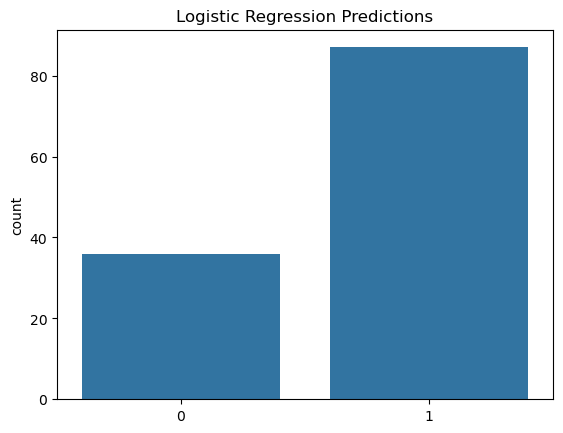

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=y_pred)

plt.title("Logistic Regression Predictions")

plt.show()

# Train Decision Tree

In [ ]:
dt_model=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(x_train_smote,y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Model Evaluation

In [ ]:
y_pred = model.predict(x_test_processed)

# Get probabilities for ROC-AUC
y_prob = model.predict_proba(x_test_processed)[:, 1]

print("\n----- Decision Tree RESULTS ----\n")

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))



----- Decision Tree RESULTS ----

Accuracy Score:
0.8211382113821138

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123


Confusion Matrix:
[[26 12]
 [10 75]]

ROC-AUC Score:
0.8758513931888545


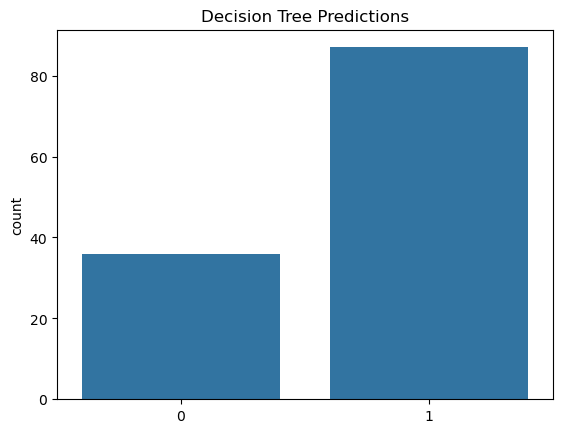

In [ ]:
sns.countplot(x=y_pred)

plt.title("Decision Tree Predictions")

plt.show()

# Train Random Forest model

In [ ]:
rf_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(x_train_smote,y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = model.predict(x_test_processed)

# Get probabilities for ROC-AUC
y_prob = model.predict_proba(x_test_processed)[:, 1]

print("\n----- RANDOM FOREST RESULTS ----\n")

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))



----- RANDOM FOREST RESULTS ----

Accuracy Score:
0.8211382113821138

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123


Confusion Matrix:
[[26 12]
 [10 75]]

ROC-AUC Score:
0.8758513931888545


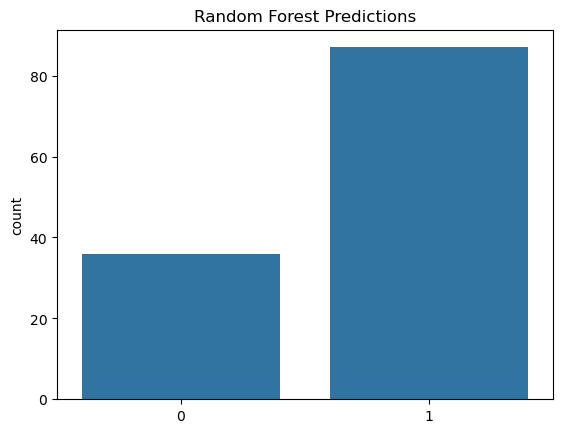

In [ ]:
sns.countplot(x=y_pred)

plt.title("Random Forest Predictions")

plt.show()

# Feature Importance

In [ ]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by = "Coefficient",
    ascending = False
)
print("\nTop Important Features:\n")

print(coefficients.head(10))


Top Important Features:

                         Feature  Coefficient
4            num__Credit_History     1.264772
18  cat__Property_Area_Semiurban     0.485655
11             cat__Dependents_2     0.276412
13       cat__Education_Graduate     0.176153
0           num__ApplicantIncome     0.144487
8               cat__Married_Yes     0.143198
12            cat__Dependents_3+     0.132878
5             cat__Gender_Female     0.074236
15         cat__Self_Employed_No     0.025427
3          num__Loan_Amount_Term    -0.015256


# Model Comparision

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Train your models
log_reg_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

log_reg_model.fit(x_train_processed, y_train)
dt_model.fit(x_train_processed, y_train)
rf_model.fit(x_train_processed, y_train)

# Generate probability predictions
y_prob = log_reg_model.predict_proba(x_test_processed)[:, 1]   # Logistic Regression
dt_prob = dt_model.predict_proba(x_test_processed)[:, 1]       # Decision Tree
rf_prob = rf_model.predict_proba(x_test_processed)[:, 1]       # Random Forest

# Calculate ROC-AUC scores
log_reg_auc = roc_auc_score(y_test, y_prob)
dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

# Build results DataFrame
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "ROC-AUC": [log_reg_auc, dt_auc, rf_auc]
})

print("MODEL COMPARISON")
print(results)

MODEL COMPARISON
                 Model   ROC-AUC
0  Logistic Regression  0.852322
1        Decision Tree  0.677709
2        Random Forest  0.782353


# Class Distribution

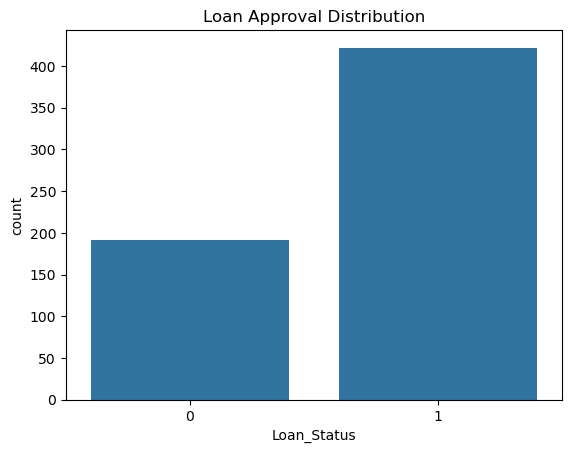

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Loan Approval Distribution")

plt.show()

# Model Comparision Chart

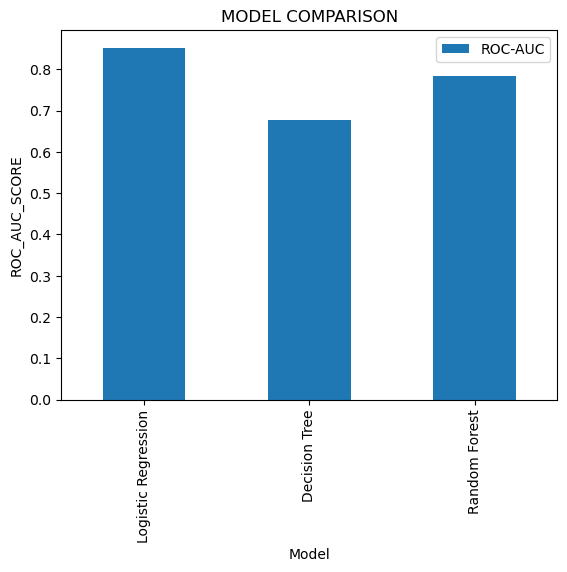

In [ ]:
results.plot(
    x="Model",
    y= "ROC-AUC",
    kind="bar"
)

plt.title("MODEL COMPARISON")
plt.ylabel("ROC_AUC_SCORE")
plt.show()

# Business Interpretat

In [ ]:
Applicants with strong credit history are more likely to receive loan approval.
Higher applicant income positively impacts approval probability.
Lower loan amount and balanced debt ratio reduce lending risk.
Logistic Regression provides better interpretability for financial institutions.
Random Forest captures complex relationships and improves prediction accuracy.